# Exploratory Data Analysis — Diabetes 130-US Hospitals

This notebook performs EDA on the `diabetic_data.csv` dataset to support the MLOps Hospital Readmission Proposal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("diabetic_data.csv")
ids_adm = pd.read_csv("IDS_mapping.csv", nrows=8, names=["id", "description"], skiprows=1)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Dataset Overview

In [3]:
print(f"Total encounters : {len(df):,}")
print(f"Unique patients  : {df['patient_nbr'].nunique():,}")
print(f"Multi-encounter  : {(df['patient_nbr'].value_counts() > 1).sum():,}")
print(f"Max per patient  : {df['patient_nbr'].value_counts().max()}")
print(f"\nColumns ({df.shape[1]}):")
print(list(df.columns))

Total encounters : 101,766
Unique patients  : 71,518
Multi-encounter  : 16,773
Max per patient  : 40

Columns (50):
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [4]:
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

## 2. Target Variable

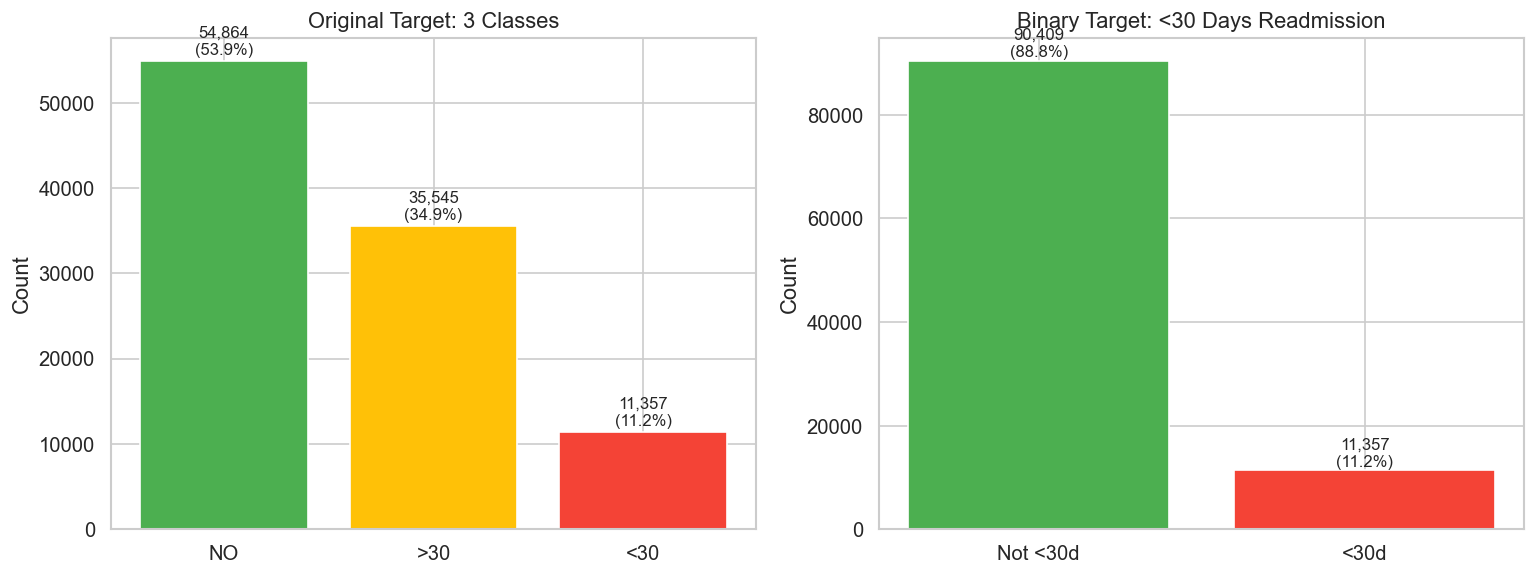


Positive class rate: 11.2%


In [5]:
target_counts = df["readmitted"].value_counts()
target_pct = df["readmitted"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Original 3-class
colors_3 = ["#4CAF50", "#FFC107", "#F44336"]
order_3 = ["NO", ">30", "<30"]
axes[0].bar(order_3, [target_counts[k] for k in order_3], color=colors_3, edgecolor="white")
for i, k in enumerate(order_3):
    axes[0].text(i, target_counts[k] + 800, f"{target_counts[k]:,}\n({target_pct[k]:.1f}%)",
                 ha="center", fontsize=10)
axes[0].set_title("Original Target: 3 Classes")
axes[0].set_ylabel("Count")

# Binary
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
binary_counts = df["readmit_30"].value_counts().sort_index()
binary_pct = df["readmit_30"].value_counts(normalize=True).sort_index() * 100
labels_bin = ["Not <30d", "<30d"]
colors_bin = ["#4CAF50", "#F44336"]
axes[1].bar(labels_bin, binary_counts.values, color=colors_bin, edgecolor="white")
for i, (cnt, pct) in enumerate(zip(binary_counts.values, binary_pct.values)):
    axes[1].text(i, cnt + 800, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=10)
axes[1].set_title("Binary Target: <30 Days Readmission")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_target_distribution.png", bbox_inches="tight")
plt.show()
print(f"\nPositive class rate: {df['readmit_30'].mean()*100:.1f}%")

## 3. Missing Values

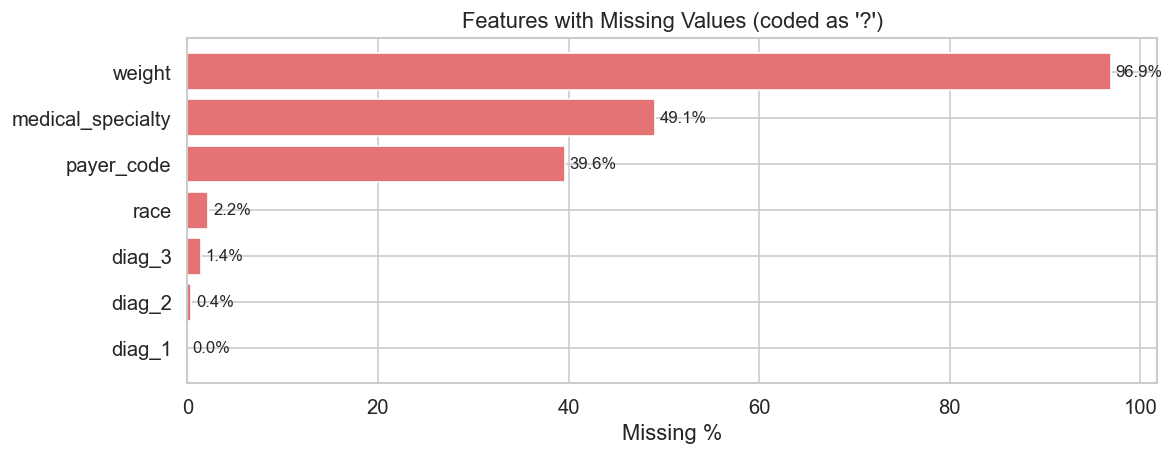

,missing_count,missing_pct
weight,98569,96.9
medical_specialty,49949,49.1
payer_code,40256,39.6
race,2273,2.2
diag_3,1423,1.4
diag_2,358,0.4
diag_1,21,0.0


In [6]:
q_counts = (df == "?").sum()
q_pct = (df == "?").mean() * 100
missing_df = pd.DataFrame({"missing_count": q_counts, "missing_pct": q_pct.round(1)})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index[::-1], missing_df["missing_pct"][::-1], color="#E57373", edgecolor="white")
for bar, pct in zip(bars, missing_df["missing_pct"][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Missing %")
ax.set_title("Features with Missing Values (coded as '?')")
plt.tight_layout()
plt.savefig("eda_missing_values.png", bbox_inches="tight")
plt.show()

missing_df

## 4. Numeric Features

In [7]:
num_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
            "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

df[num_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


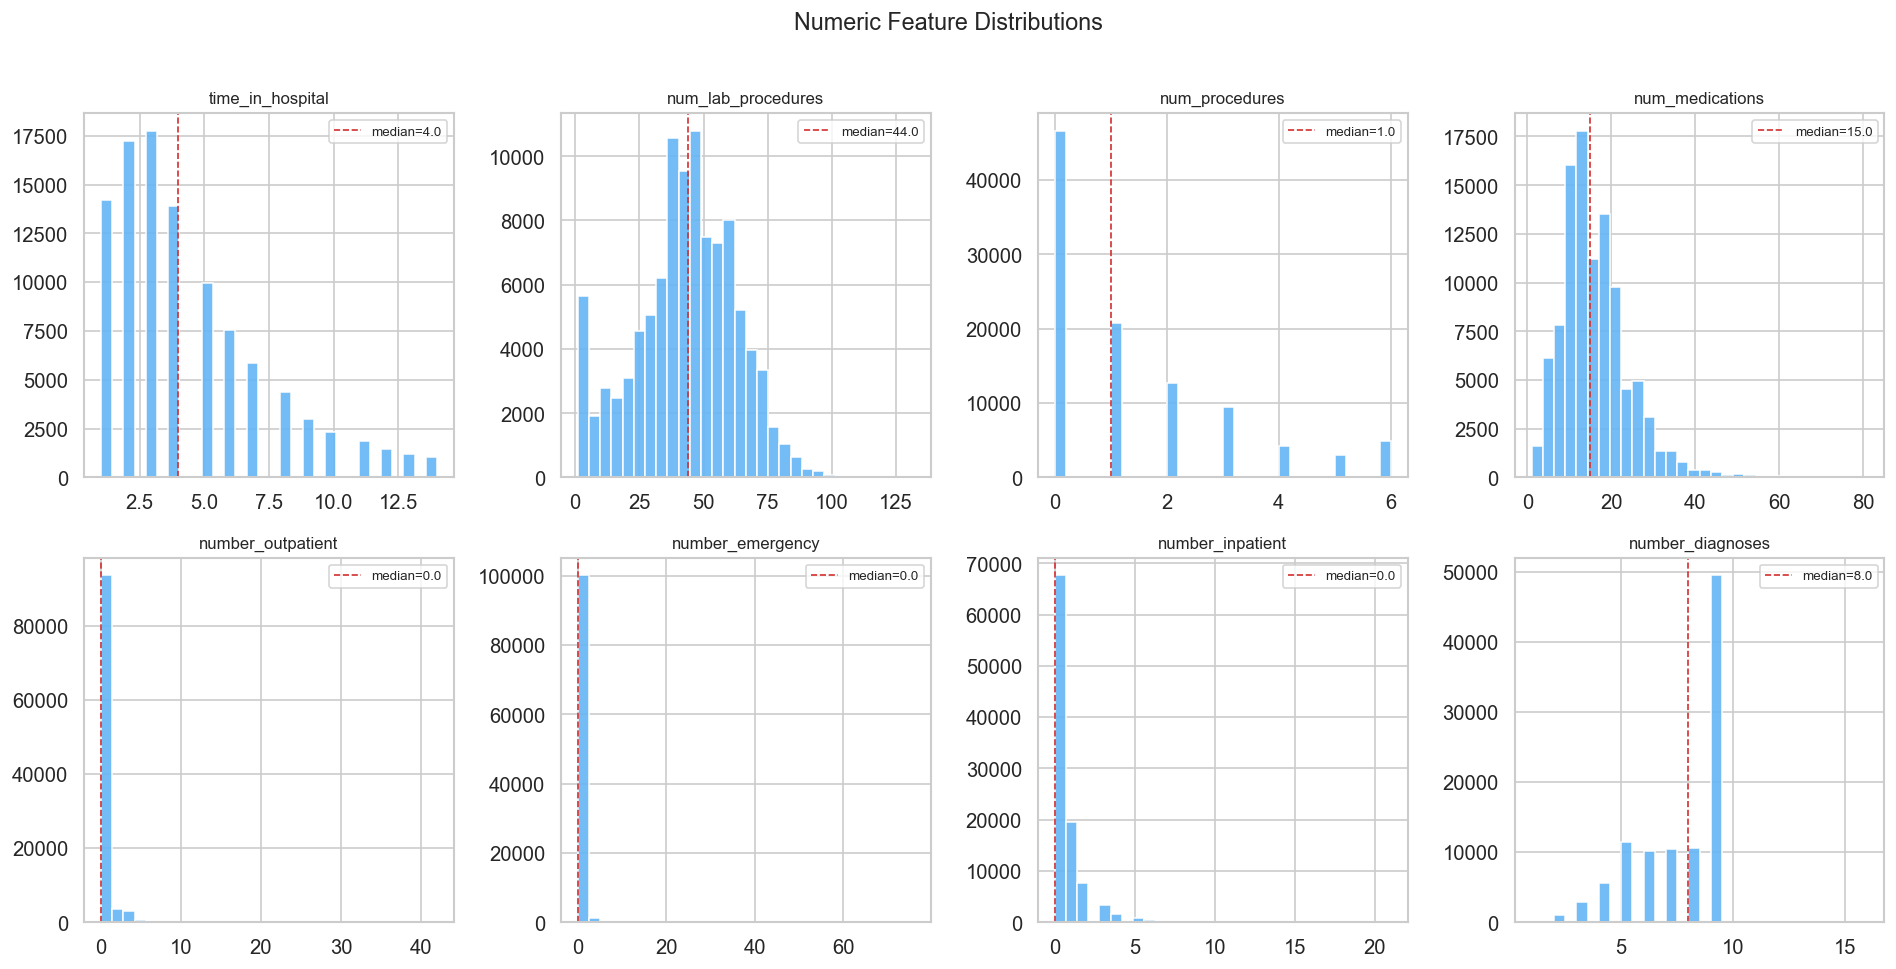

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    ax.hist(df[col], bins=30, color="#64B5F6", edgecolor="white", alpha=0.9)
    ax.set_title(col, fontsize=10)
    ax.axvline(df[col].median(), color="#D32F2F", linestyle="--", linewidth=1, label=f"median={df[col].median():.1f}")
    ax.legend(fontsize=8)
plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_numeric_distributions.png", bbox_inches="tight")
plt.show()

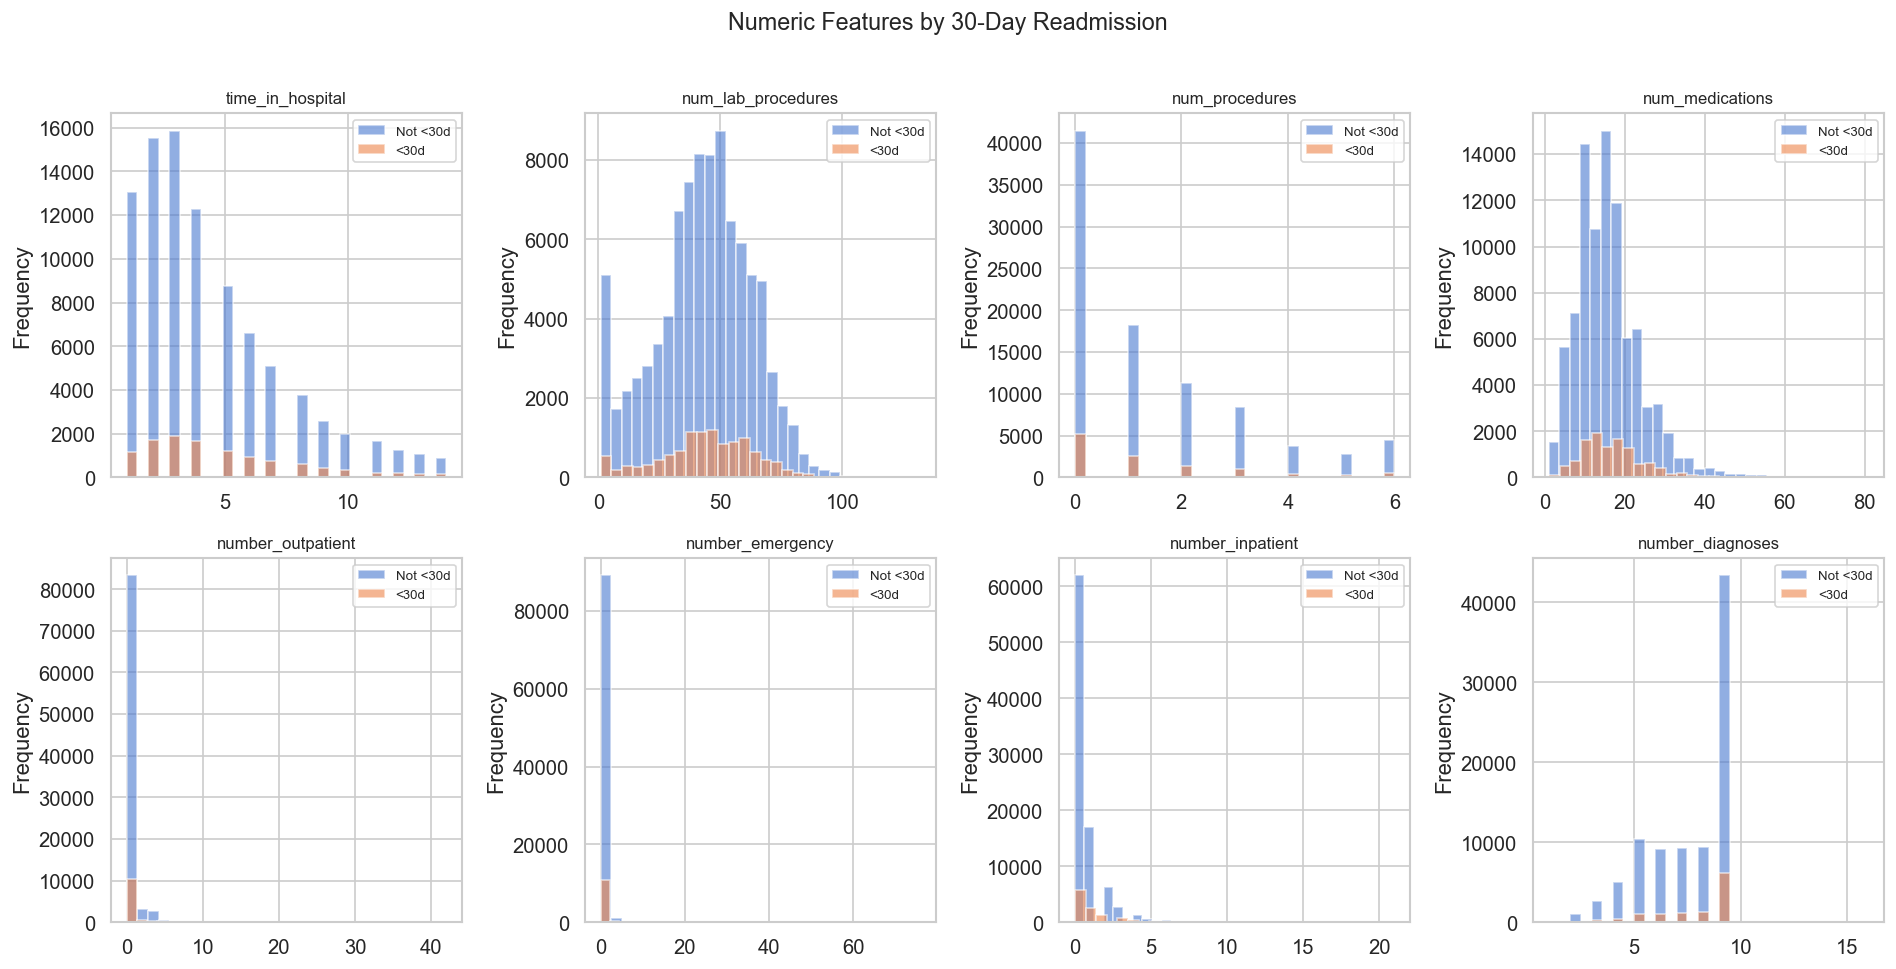

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    df.groupby("readmit_30")[col].plot.hist(bins=30, alpha=0.6, ax=ax, legend=True)
    ax.set_title(col, fontsize=10)
    ax.legend(["Not <30d", "<30d"], fontsize=8)
plt.suptitle("Numeric Features by 30-Day Readmission", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_numeric_by_target.png", bbox_inches="tight")
plt.show()

## 5. Demographics

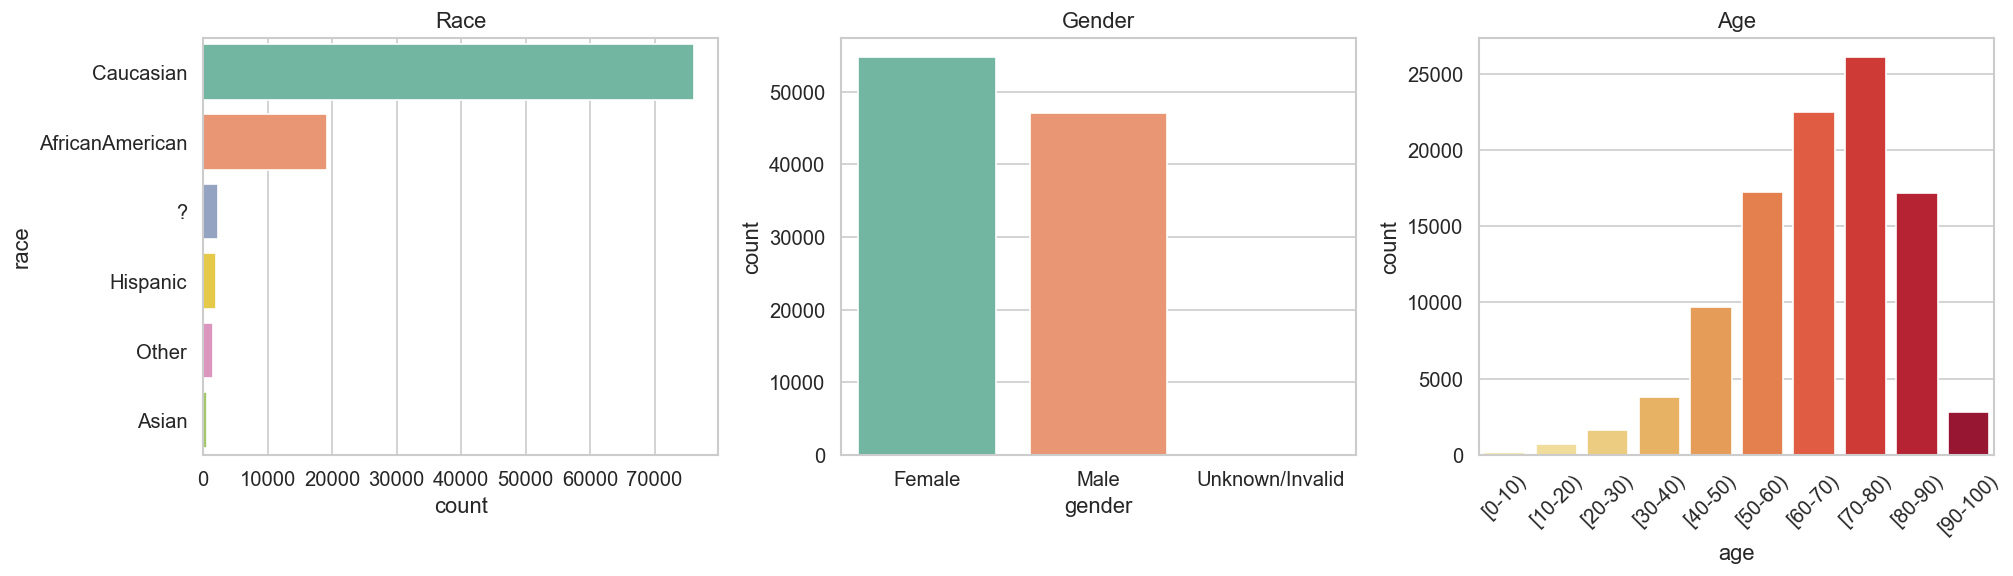

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Race
race_order = df["race"].value_counts().index
sns.countplot(data=df, y="race", order=race_order, ax=axes[0], hue="race", palette="Set2", legend=False)
axes[0].set_title("Race")

# Gender
sns.countplot(data=df, x="gender", ax=axes[1], hue="gender", palette="Set2", legend=False)
axes[1].set_title("Gender")

# Age
age_order = sorted(df["age"].unique())
sns.countplot(data=df, x="age", order=age_order, ax=axes[2], hue="age", palette="YlOrRd", legend=False)
axes[2].set_title("Age")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("eda_demographics.png", bbox_inches="tight")
plt.show()

## 6. HbA1c and Glucose

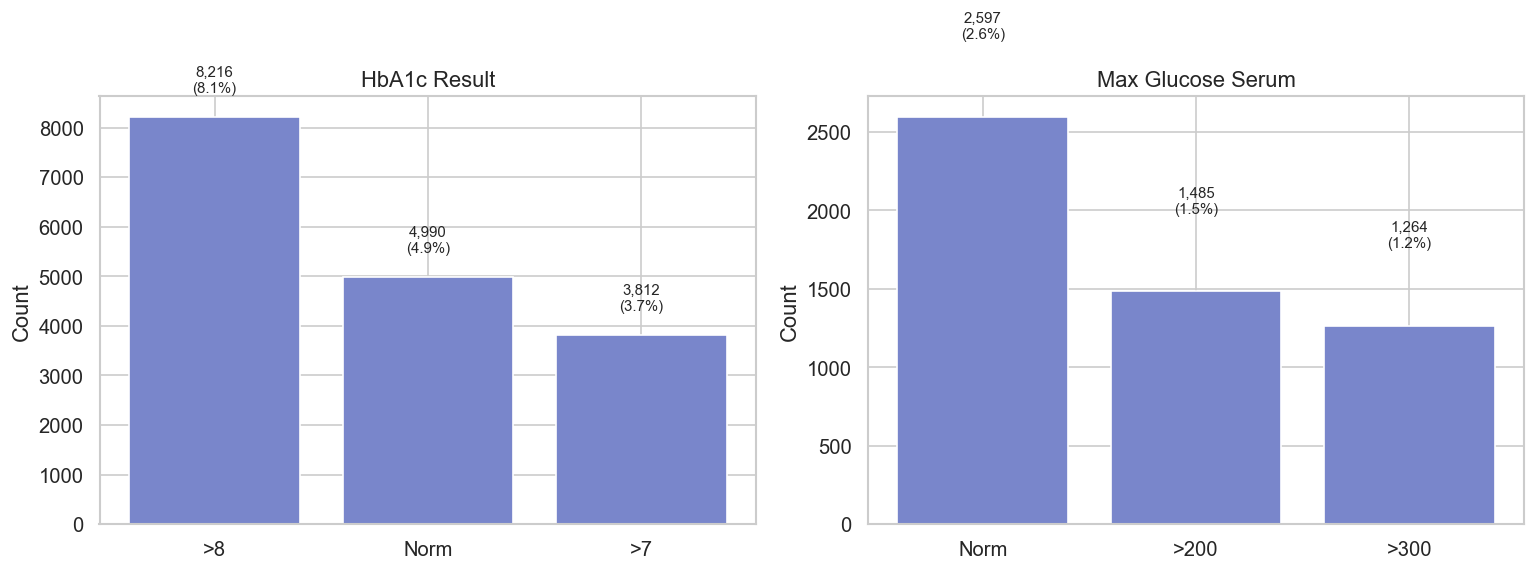

HbA1c 'None' (not tested): 0 (0.0%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, ["A1Cresult", "max_glu_serum"],
                           ["HbA1c Result", "Max Glucose Serum"]):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color="#7986CB", edgecolor="white")
    for i, (k, v) in enumerate(vc.items()):
        ax.text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_lab_results.png", bbox_inches="tight")
plt.show()

print(f"HbA1c 'None' (not tested): {(df['A1Cresult']=='None').sum():,} ({(df['A1Cresult']=='None').mean()*100:.1f}%)")

## 7. Medication Flags

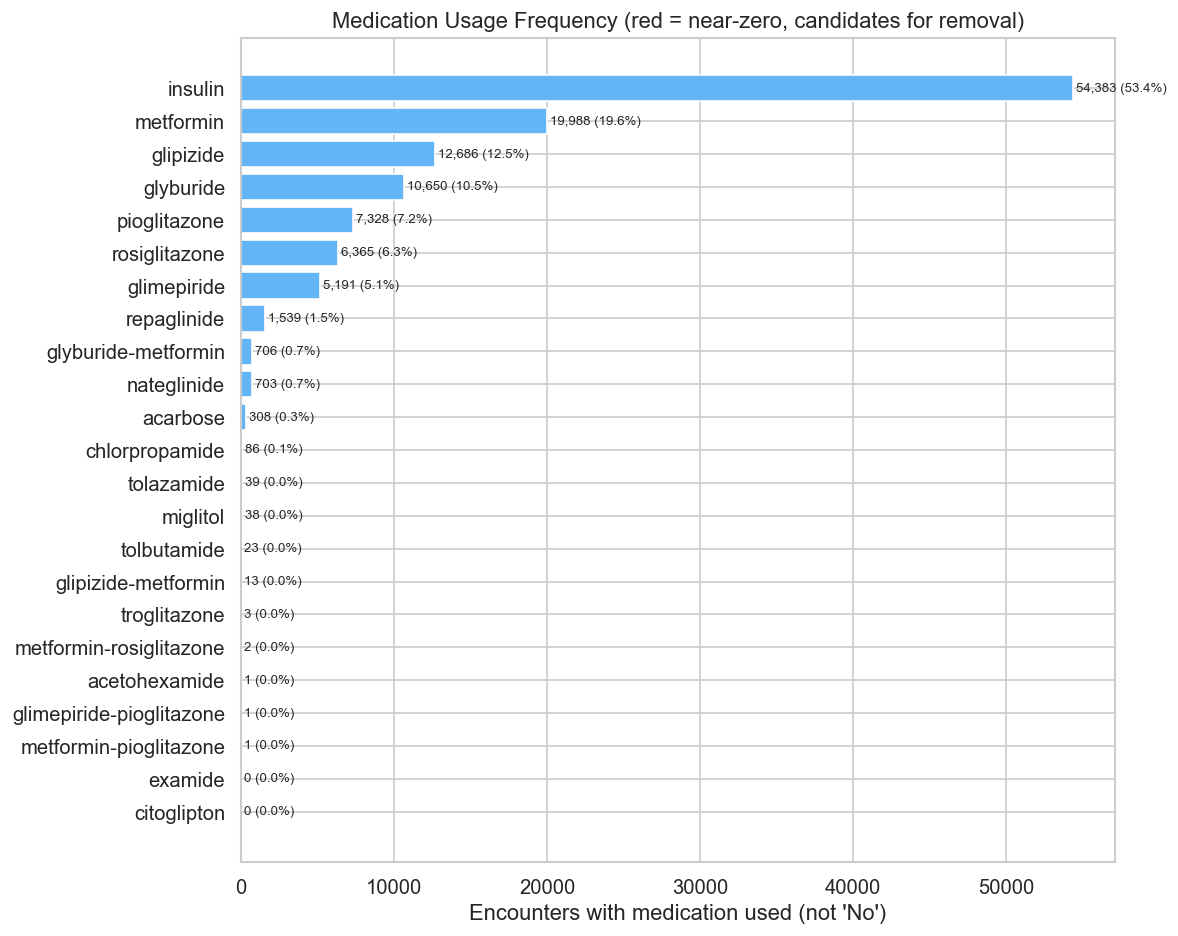


Near-zero-variance medications (<=3 non-'No' records):
citoglipton                 0
examide                     0
metformin-pioglitazone      1
glimepiride-pioglitazone    1
acetohexamide               1
metformin-rosiglitazone     2
troglitazone                3


In [12]:
med_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
            "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
            "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
            "examide", "citoglipton", "insulin", "glyburide-metformin",
            "glipizide-metformin", "glimepiride-pioglitazone",
            "metformin-rosiglitazone", "metformin-pioglitazone"]

med_usage = pd.Series({c: (df[c] != "No").sum() for c in med_cols}).sort_values(ascending=True)
med_pct = (med_usage / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#E57373" if v <= 3 else "#64B5F6" for v in med_usage.values]
ax.barh(med_usage.index, med_usage.values, color=colors, edgecolor="white")
for i, (name, val) in enumerate(med_usage.items()):
    ax.text(val + 200, i, f"{val:,} ({med_pct[name]}%)", va="center", fontsize=8)
ax.set_xlabel("Encounters with medication used (not 'No')")
ax.set_title("Medication Usage Frequency (red = near-zero, candidates for removal)")
plt.tight_layout()
plt.savefig("eda_medication_flags.png", bbox_inches="tight")
plt.show()

print("\nNear-zero-variance medications (<=3 non-'No' records):")
print(med_usage[med_usage <= 3].to_string())

## 8. ICD-9 Diagnosis Cardinality

In [13]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"{col}: {df[col].nunique()} unique codes")

print("\nTop 10 primary diagnoses (diag_1):")
print(df["diag_1"].value_counts().head(10).to_string())

diag_1: 717 unique codes
diag_2: 749 unique codes
diag_3: 790 unique codes

Top 10 primary diagnoses (diag_1):
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028


## 9. 30-Day Readmission Rate by Key Groups

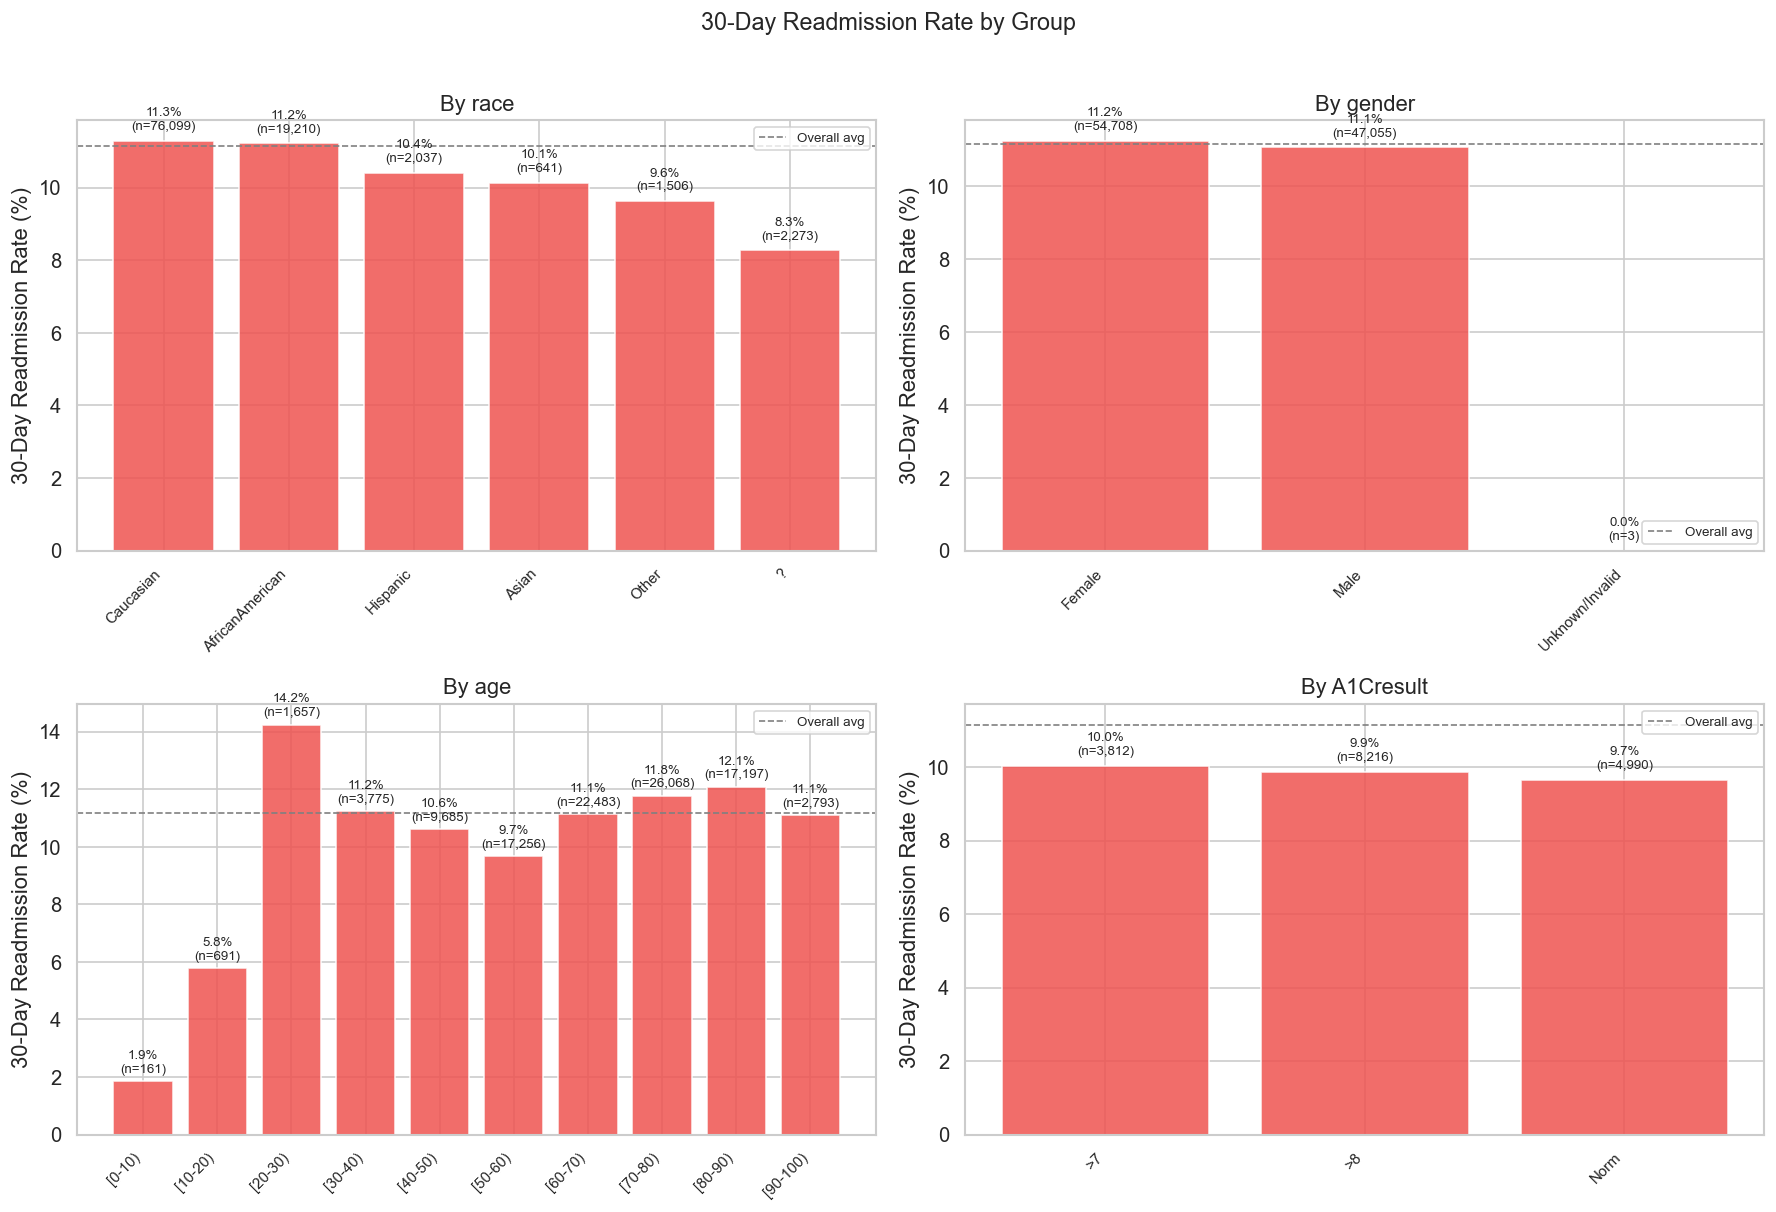

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

group_cols = ["race", "gender", "age", "A1Cresult"]
for ax, col in zip(axes.ravel(), group_cols):
    grp = df.groupby(col)["readmit_30"].agg(["mean", "count"])
    grp["mean"] = grp["mean"] * 100
    if col == "age":
        grp = grp.sort_index()
    else:
        grp = grp.sort_values("mean", ascending=False)

    bars = ax.bar(range(len(grp)), grp["mean"], color="#EF5350", edgecolor="white", alpha=0.85)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("30-Day Readmission Rate (%)")
    ax.set_title(f"By {col}")
    ax.axhline(df["readmit_30"].mean() * 100, color="gray", linestyle="--", linewidth=1, label="Overall avg")
    ax.legend(fontsize=8)

    for i, (idx, row) in enumerate(grp.iterrows()):
        ax.text(i, row["mean"] + 0.3, f"{row['mean']:.1f}%\n(n={int(row['count']):,})",
                ha="center", fontsize=8)

plt.suptitle("30-Day Readmission Rate by Group", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_readmission_by_group.png", bbox_inches="tight")
plt.show()

## 10. Patient Overlap & Leakage Risk

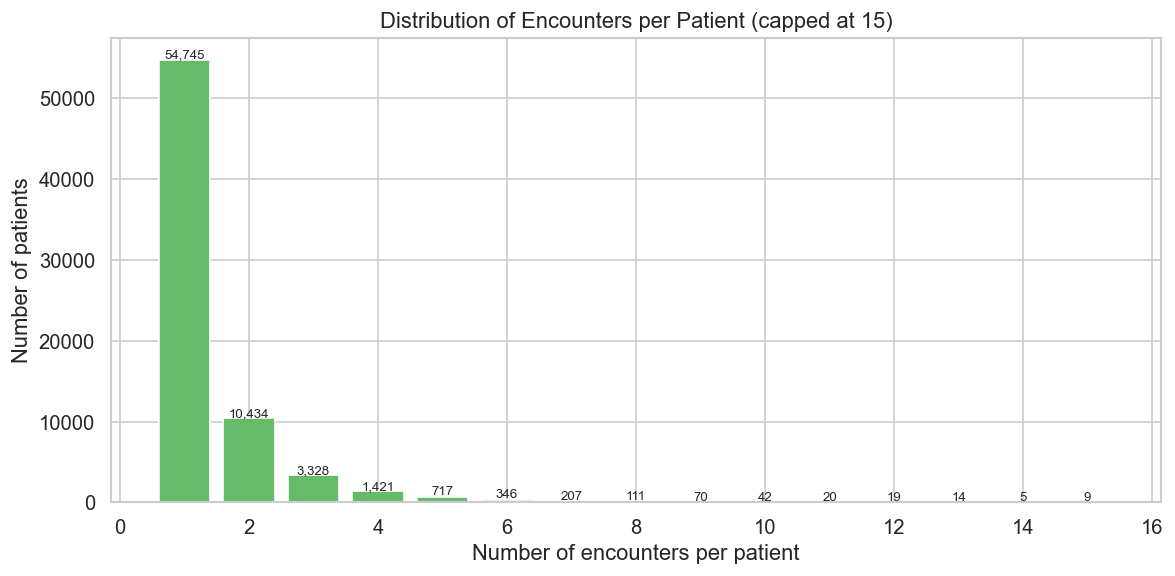

Patients with 1 encounter : 54,745 (76.5%)
Patients with 2+ encounters: 16,773 (23.5%)
Max encounters per patient : 40


In [15]:
enc_per_patient = df["patient_nbr"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
enc_dist = enc_per_patient.value_counts().sort_index()
ax.bar(enc_dist.index[:15], enc_dist.values[:15], color="#66BB6A", edgecolor="white")
ax.set_xlabel("Number of encounters per patient")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Encounters per Patient (capped at 15)")
for i, (x, y) in enumerate(zip(enc_dist.index[:15], enc_dist.values[:15])):
    ax.text(x, y + 200, f"{y:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda_patient_overlap.png", bbox_inches="tight")
plt.show()

print(f"Patients with 1 encounter : {(enc_per_patient == 1).sum():,} ({(enc_per_patient == 1).mean()*100:.1f}%)")
print(f"Patients with 2+ encounters: {(enc_per_patient > 1).sum():,} ({(enc_per_patient > 1).mean()*100:.1f}%)")
print(f"Max encounters per patient : {enc_per_patient.max()}")

## 11. Correlation Matrix (Numeric Features)

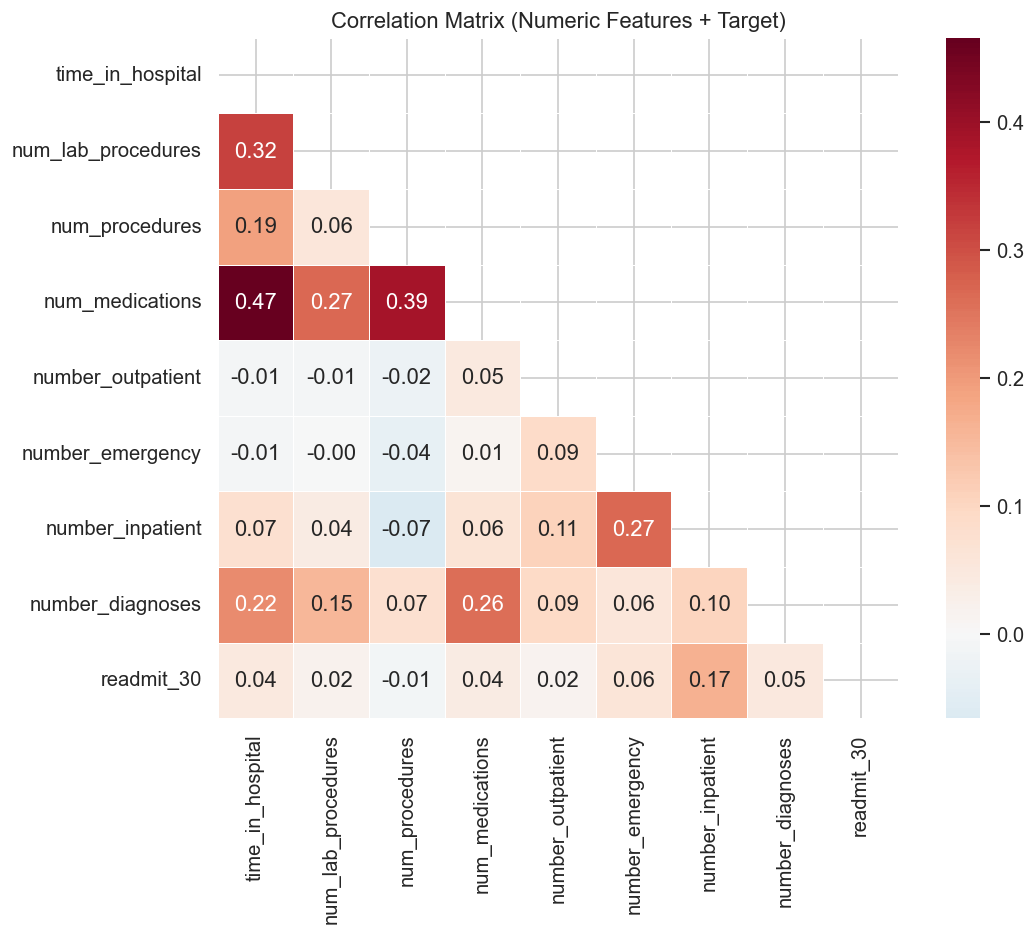

In [16]:
corr_cols = num_cols + ["readmit_30"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.savefig("eda_correlation_matrix.png", bbox_inches="tight")
plt.show()

## 12. Summary of Key Findings

1. **Class imbalance confirmed**: 11.2% positive (30-day readmission)
2. **Drop `weight`** — 96.9% missing
3. **HbA1c missingness is 83.3%**, not ~70% — treat as informational "not tested"
4. **`medical_specialty` (49.1%) and `payer_code` (39.6%)** need imputation strategy
5. **Patient-level split required** — 16,773 patients have multiple encounters; random encounter-level split would leak
6. **5 near-zero-variance medication columns** to drop: `examide`, `citoglipton`, `troglitazone`, `metformin-pioglitazone`, `glimepiride-pioglitazone`
7. **Readmission rates fairly consistent across race/gender** (~10–11%); small subgroups (Asian, Hispanic) need bootstrapped fairness tests
8. **Prior inpatient visits (`number_inpatient`)** shows the strongest numeric correlation with 30-day readmission
9. **ICD-9 codes have 700+ unique values** per diagnosis slot — must be grouped (CCS) before modeling